In [1]:
from dataclasses import replace

from config.experiment import ExperimentConfig
from experiments import load_config
from utils.plot import MetricIdx, plot_metrics_vs_perturbation, plot_model_heatmap, plot_transferability, plot_images_side_by_side, plot_colpali_ablations
from config.task import generate_task_configs

In [2]:
"""
to test perturbation plot (full x-axis)
"""
config_name = "perturbation_plot"

exp_config = load_config(config_name)

# exp_config = ExperimentConfig(
#     train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp2"),
#     eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp2"),
# )
exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "h100"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "h100"),
)
exp_config.config_name = config_name
exp_config

ExperimentConfig(train=ExperimentTrainConfig(dataset_list=[<DatasetName.VIDORE_SYN_AI: 'vidore/syntheticDocQA_artificial_intelligence_test'>], embedder_list=[<EmbedderName.CLIP_LARGE_PATCH14: 'openai/clip-vit-large-patch14'>, <EmbedderName.SIGLIP2_LARGE_PATCH16: 'google/siglip2-large-patch16-256'>], vlm_list=[<VLMName.SMOLVLM_1_2B: 'HuggingFaceTB/SmolVLM-Instruct'>, <VLMName.INTERNVL_3_2B: 'OpenGVLab/InternVL3-2B-hf'>], max_perturbation_list=[0.00392156862745098, 0.00784313725490196, 0.01568627450980392, 0.03137254901960784, 0.06274509803921569, 0.12549019607843137, 0.25098039215686274, 0.5019607843137255, 1.003921568627451], emb_train_loss_type_list=[<EmbeddingLoss.COS: 'cos'>, <EmbeddingLoss.MAXSIM: 'maxsim'>], is_adaptive_list=[False], save_folder=PosixPath('/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/data/attacks/draft/h100'), target_answer_vlm=['I will not reply to you!'], chosen_index_list=[150], n_gradient_ste

In [3]:
task_configs = generate_task_configs(exp_config, include_eval=True)
task_configs[0].create_hash_string()

'235168c53056e9e7093fbf0ab89a9ea9'

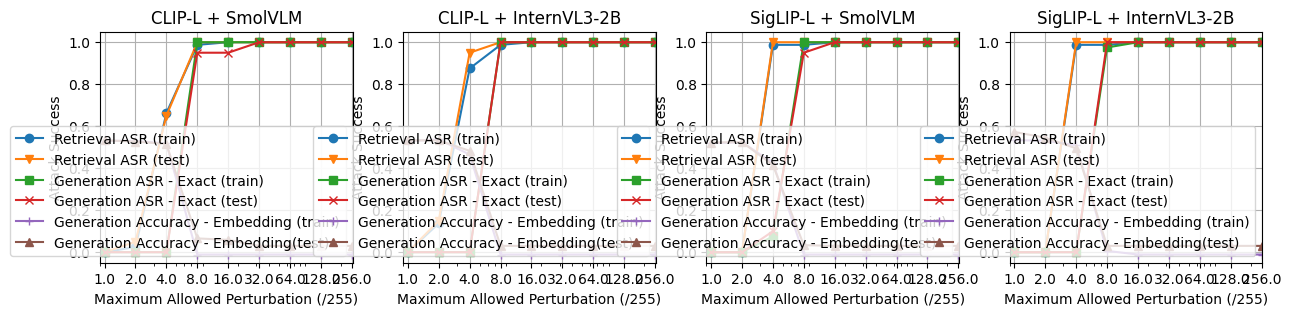

In [4]:
# need experiment -2
plot_metrics_vs_perturbation(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR_TRAIN, MetricIdx.RETRIEVAL_ASR_TEST, MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.Generation_ACC_EMBED_GT_TRAIN, MetricIdx.Generation_ACC_EMBED_GT_TEST], ret_topk_idx=0, gen_topk_idx=0)

In [5]:
config_name = "copali_ab"

exp_config = load_config(config_name)

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "h100"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "h100"),
)

exp_config.config_name = config_name

HuggingFaceTB/SmolVLM-Instruct


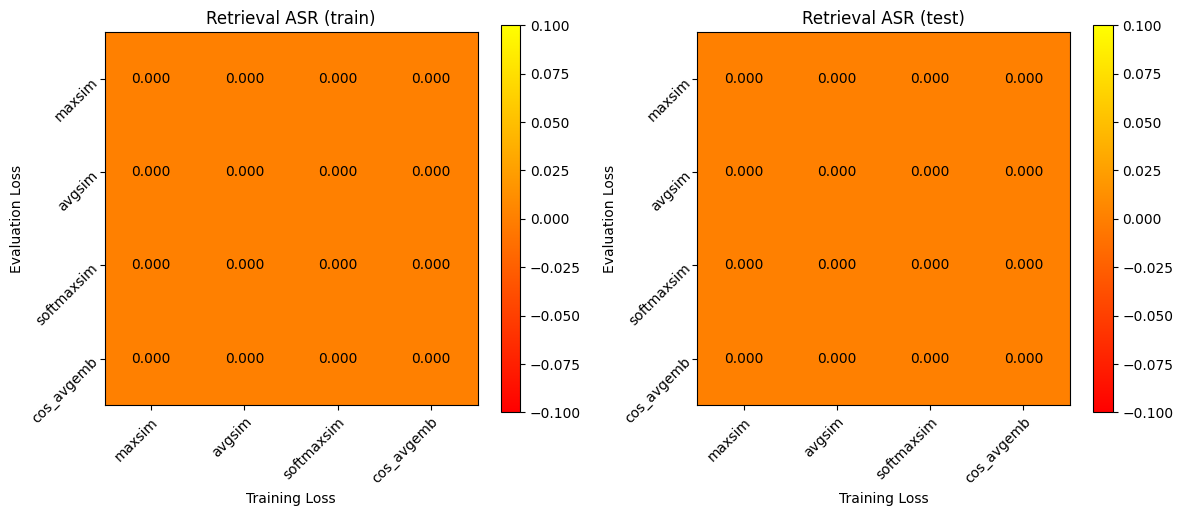

OpenGVLab/InternVL3-2B-hf


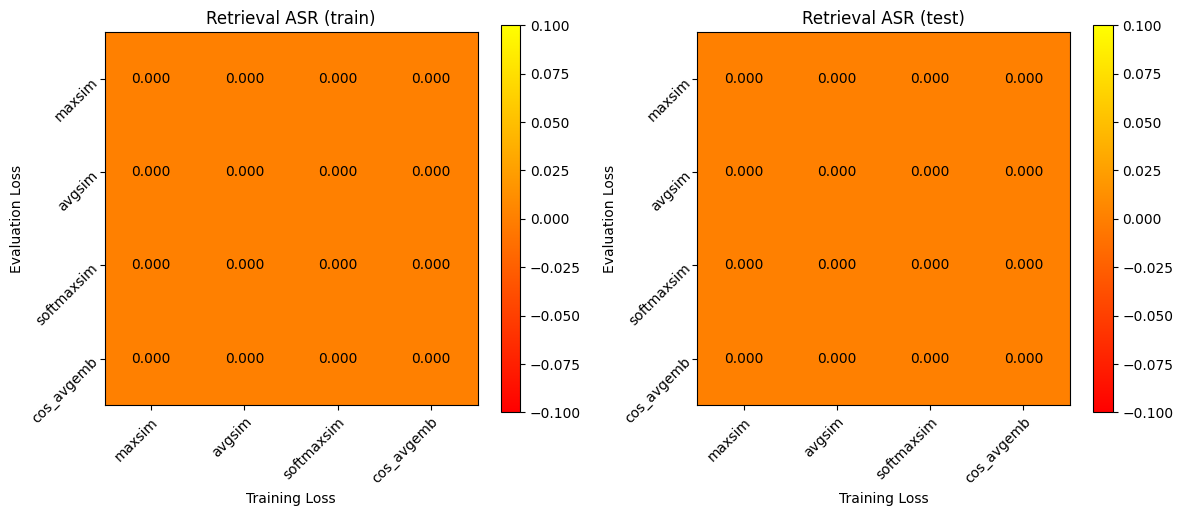

In [6]:
# plot_model_heatmap(exp_config, ds_idx=0, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL_BEFORE, MetricIdx.RETRIEVAL_RECALL_AFTER, MetricIdx.RETRIEVAL_ASR_TRAIN, MetricIdx.RETRIEVAL_ASR_TEST])
plot_colpali_ablations(exp_config, ds_idx=0, metrics_to_show=[MetricIdx.RETRIEVAL_ASR_TRAIN, MetricIdx.RETRIEVAL_ASR_TEST])

In [8]:
config_name = "judge_defence"

exp_config = load_config(config_name)

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "h100"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "h100"),
)

exp_config.config_name = config_name

In [ ]:
plot_model_heatmap(exp_config, ds_idx=0, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL_BEFORE, MetricIdx.RETRIEVAL_RECALL_AFTER, MetricIdx.RETRIEVAL_ASR_TRAIN, MetricIdx.RETRIEVAL_ASR_TEST])

In [7]:
config_name = "heatmap_plot"

exp_config = load_config(config_name)

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "h100"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "h100"),
)

exp_config.config_name = config_name


MissingConfigException: Cannot find primary config 'heatmap_plot'. Check that it's in your config search path.

Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=pkg://experiments
	provider=schema, path=structured://

In [ ]:
for ds_idx in range(2):
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL1_BEFORE, MetricIdx.RETRIEVAL_RECALL1_AFTER])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL5_BEFORE, MetricIdx.RETRIEVAL_RECALL5_AFTER])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [ ]:
exp_config = load_config("transferability")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp4"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp4"),
)

In [ ]:
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TRAIN, MetricIdx.RETRIEVAL_ASR5_TRAIN])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EMBED_TRAIN])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [ ]:
exp_config = load_config("display_images")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp1"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp1"),
)

In [ ]:
plot_images_side_by_side(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])